<a href="https://colab.research.google.com/github/Jupiter1711/VAR2026/blob/main/VAR2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi
!nvcc --version

Fri Jul 24 14:00:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT = '/content/drive/MyDrive/VAR2026'
DATA_DRIVE = f'{DRIVE_ROOT}/VAI_NVS_DATA_ROUND2'   # data goc tren Drive
DATA_LOCAL = '/content/data'                        # ban sao tren dia local
OUTPUT     = f'{DRIVE_ROOT}/output'                 # checkpoint - luu ve Drive
SUBMISSION = f'{DRIVE_ROOT}/submission'             # anh render

for p in (OUTPUT, DATA_LOCAL, SUBMISSION, '/content/tools'):
    os.makedirs(p, exist_ok=True)

assert os.path.isdir(DATA_DRIVE), f'Khong thay data tai {DATA_DRIVE}'
SCENES = sorted(d for d in os.listdir(DATA_DRIVE) if os.path.isdir(f'{DATA_DRIVE}/{d}'))
print(f'Tim thay {len(SCENES)} scene:', SCENES)

Mounted at /content/drive
Tim thay 7 scene: ['HCM0421', 'HCM0539', 'HCM0540', 'HCM0644', 'HCM0674', 'bonsai', 'chair']


In [ ]:
%cd /content
!git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting 2>/dev/null || echo 'repo da ton tai'
!pip install -q plyfile
!pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization
!pip install -q /content/gaussian-splatting/submodules/simple-knn
!pip install -q gsplat lpips scikit-image

import torch
print('CUDA:', torch.cuda.is_available(), '|', torch.cuda.get_device_name(0))

/content
Submodule path 'SIBR_viewers': checked out 'd8856f60c5384cc1975439193bb627d77d917d77'
Submodule path 'submodules/diff-gaussian-rasterization': checked out '9c5c2028f6fbee2be239bc4c9421ff894fe4fbe0'
Submodule path 'submodules/diff-gaussian-rasterization/third_party/glm': checked out '5c46b9c07008ae65cb81ab79cd677ecc1934b903'
Submodule path 'submodules/fused-ssim': checked out '1272e21a282342e89537159e4bad508b19b34157'
Submodule path 'submodules/simple-knn': checked out '86710c2d4b46680c02301765dd79e465819c8f19'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.6 MB/s eta 0:00:00

In [ ]:
path = '/content/gaussian-splatting/scene/dataset_readers.py'
src = open(path).read()

if 'VAR2026_SKIP_MISSING' in src:
    print('Repo da duoc va truoc do')
else:
    out, patched = [], 0
    for ln in src.split('\n'):
        out.append(ln)
        if 'image_path = os.path.join(images_folder' in ln:
            ind = ln[:len(ln) - len(ln.lstrip())]
            out.append(f'{ind}if not os.path.exists(image_path):  # VAR2026_SKIP_MISSING')
            out.append(f'{ind}    continue')
            patched += 1
    assert patched, 'Khong tim thay dong can va '
    open(path, 'w').write('\n'.join(out))
    print(f'Da va {patched} cho')

Da va 1 cho


In [ ]:
path = '/content/gaussian-splatting/scene/dataset_readers.py'
src = open(path).read()
if 'VAR2026_EXTRA_MODELS' in src:
    print('Da va truoc do')
else:
    old = '''        else:
            assert False, "Colmap camera model not handled: only undistorted datasets (PINHOLE or SIMPLE_PINHOLE cameras) supported!"'''
    new = '''        elif intr.model in ("OPENCV", "OPENCV_FISHEYE", "FULL_OPENCV", "RADIAL",
                            "SIMPLE_RADIAL", "PINHOLE_RADIAL"):  # VAR2026_EXTRA_MODELS
            if intr.model in ("SIMPLE_RADIAL", "RADIAL"):
                focal_length_x = intr.params[0]
                focal_length_y = intr.params[0]
            else:
                focal_length_x = intr.params[0]
                focal_length_y = intr.params[1]
            FovY = focal2fov(focal_length_y, height)
            FovX = focal2fov(focal_length_x, width)
        else:
            assert False, f"Colmap camera model not handled: {intr.model}"'''
    assert old in src, 'Khong tim thay doan can va - gui lai noi dung ham readColmapCameras'
    open(path, 'w').write(src.replace(old, new))
    print('Da va xong')

Da va xong


In [ ]:
!mkdir -p /content/tools

In [ ]:
%%writefile /content/tools/pose_utils.py

import csv
from dataclasses import dataclass

import numpy as np


@dataclass
class TestPose:
    image_name: str
    qvec: np.ndarray  # (4,) [qw, qx, qy, qz]
    tvec: np.ndarray  # (3,) [tx, ty, tz]
    fx: float
    fy: float
    cx: float
    cy: float
    width: int
    height: int


def load_test_poses(csv_path):
    """Đọc test_poses.csv -> list[TestPose]. Chấp nhận header có/không, có khoảng trắng."""
    poses = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            row = [c.strip() for c in row]
            # Bỏ qua dòng header nếu có
            if row[0].lower() in ("image_name", "name", "filename"):
                continue
            if len(row) < 14:
                raise ValueError(
                    f"Dòng CSV không đủ 14 cột ({len(row)} cột): {row}"
                )
            poses.append(
                TestPose(
                    image_name=row[0],
                    qvec=np.array([float(x) for x in row[1:5]], dtype=np.float64),
                    tvec=np.array([float(x) for x in row[5:8]], dtype=np.float64),
                    fx=float(row[8]),
                    fy=float(row[9]),
                    cx=float(row[10]),
                    cy=float(row[11]),
                    width=int(float(row[12])),
                    height=int(float(row[13])),
                )
            )
    if not poses:
        raise ValueError(f"Không đọc được pose nào từ {csv_path}")
    return poses


def qvec2rotmat(qvec):
    """COLMAP quaternion [qw,qx,qy,qz] -> ma trận xoay 3x3 (world-to-camera)."""
    w, x, y, z = qvec
    return np.array(
        [
            [1 - 2 * y * y - 2 * z * z, 2 * x * y - 2 * z * w, 2 * x * z + 2 * y * w],
            [2 * x * y + 2 * z * w, 1 - 2 * x * x - 2 * z * z, 2 * y * z - 2 * x * w],
            [2 * x * z - 2 * y * w, 2 * y * z + 2 * x * w, 1 - 2 * x * x - 2 * y * y],
        ],
        dtype=np.float64,
    )


def pose_to_w2c(pose: TestPose):
    """TestPose -> ma trận world-to-camera 4x4."""
    m = np.eye(4, dtype=np.float64)
    m[:3, :3] = qvec2rotmat(pose.qvec)
    m[:3, 3] = pose.tvec
    return m


def pose_to_K(pose: TestPose):
    """TestPose -> ma trận intrinsics 3x3."""
    return np.array(
        [[pose.fx, 0.0, pose.cx], [0.0, pose.fy, pose.cy], [0.0, 0.0, 1.0]],
        dtype=np.float64,
    )


Writing /content/tools/pose_utils.py


In [ ]:
%%writefile /content/tools/render_test_poses.py

import argparse
import os

import numpy as np


def load_3dgs_ply(path, max_sh_degree=3):
    """Load point_cloud.ply của 3DGS -> dict các tensor numpy."""
    from plyfile import PlyData

    ply = PlyData.read(path)
    v = ply["vertex"]
    n = v.count

    means = np.stack([v["x"], v["y"], v["z"]], axis=1).astype(np.float32)
    opacities = np.asarray(v["opacity"], dtype=np.float32)  # logit
    scales = np.stack(
        [v[f"scale_{i}"] for i in range(3)], axis=1
    ).astype(np.float32)  # log-scale
    quats = np.stack(
        [v[f"rot_{i}"] for i in range(4)], axis=1
    ).astype(np.float32)  # wxyz, chưa normalize

    # SH: f_dc (3) + f_rest (3 * (K-1)) với K = (deg+1)^2
    f_dc = np.stack([v[f"f_dc_{i}"] for i in range(3)], axis=1)  # (N, 3)
    rest_names = sorted(
        [p.name for p in v.properties if p.name.startswith("f_rest_")],
        key=lambda s: int(s.split("_")[-1]),
    )
    num_rest = len(rest_names)  # = 3 * (K - 1)
    k_minus_1 = num_rest // 3
    # Suy ra sh_degree thực tế từ số coefficient
    K = k_minus_1 + 1
    sh_degree = int(np.sqrt(K)) - 1
    assert (sh_degree + 1) ** 2 == K, f"Số SH coeff bất thường: K={K}"

    if num_rest > 0:
        f_rest = np.stack([v[nm] for nm in rest_names], axis=1)  # (N, 3*(K-1))
        # 3DGS lưu channel-major: (N, 3, K-1) -> chuyển về (N, K-1, 3)
        f_rest = f_rest.reshape(n, 3, k_minus_1).transpose(0, 2, 1)
    else:
        f_rest = np.zeros((n, 0, 3), dtype=np.float32)

    sh = np.concatenate([f_dc[:, None, :], f_rest], axis=1).astype(np.float32)  # (N, K, 3)

    print(f"Loaded {n} gaussians, sh_degree={sh_degree}")
    return {
        "means": means,
        "opacities": opacities,
        "scales": scales,
        "quats": quats,
        "sh": sh,
        "sh_degree": sh_degree,
    }


def main():
    ap = argparse.ArgumentParser(description="Render test poses từ 3DGS .ply")
    ap.add_argument("--ply", required=True, help="point_cloud.ply đã train")
    ap.add_argument("--csv", required=True, help="test_poses.csv")
    ap.add_argument("--out", required=True, help="Thư mục output PNG")
    ap.add_argument("--device", default="cuda")
    ap.add_argument(
        "--white-bg", action="store_true",
        help="Nền trắng thay vì nền đen (chọn theo cấu hình lúc train)",
    )
    args = ap.parse_args()

    import torch
    from gsplat import rasterization
    from PIL import Image

    from pose_utils import load_test_poses, pose_to_K, pose_to_w2c

    dev = torch.device(args.device)
    g = load_3dgs_ply(args.ply)

    means = torch.from_numpy(g["means"]).to(dev)
    quats = torch.from_numpy(g["quats"]).to(dev)
    quats = quats / quats.norm(dim=-1, keepdim=True)
    scales = torch.exp(torch.from_numpy(g["scales"]).to(dev))
    opacities = torch.sigmoid(torch.from_numpy(g["opacities"]).to(dev))
    sh = torch.from_numpy(g["sh"]).to(dev)  # (N, K, 3)

    poses = load_test_poses(args.csv)
    os.makedirs(args.out, exist_ok=True)

    bg = 1.0 if args.white_bg else 0.0

    with torch.no_grad():
        for p in poses:
            viewmat = torch.from_numpy(pose_to_w2c(p)).float().to(dev)[None]  # (1,4,4)
            K = torch.from_numpy(pose_to_K(p)).float().to(dev)[None]  # (1,3,3)

            renders, alphas, _ = rasterization(
                means=means,
                quats=quats,
                scales=scales,
                opacities=opacities,
                colors=sh,
                viewmats=viewmat,
                Ks=K,
                width=p.width,
                height=p.height,
                sh_degree=g["sh_degree"],
            )
            img = renders[0] + (1.0 - alphas[0]) * bg
            img = img.clamp(0.0, 1.0).cpu().numpy() # (H, W, 3)
            img = (img * 255.0 + 0.5).astype(np.uint8)

            out_path = os.path.join(args.out, p.image_name)
            os.makedirs(os.path.dirname(out_path) or args.out, exist_ok=True)
            Image.fromarray(img).save(out_path)
            print(f"  rendered {p.image_name} ({p.width}x{p.height})")

    print(f"Xong: {len(poses)} ảnh -> {args.out}")


if __name__ == "__main__":
    main()


Writing /content/tools/render_test_poses.py


In [ ]:
%%writefile /content/tools/score_local.py

import argparse
import os
import sys

import numpy as np


def list_images(root):
    """Liệt kê ảnh (đường dẫn tương đối) trong root, đệ quy."""
    exts = {".png", ".jpg", ".jpeg"}
    out = {}
    for r, _d, files in os.walk(root):
        for fn in files:
            if os.path.splitext(fn)[1].lower() in exts:
                rel = os.path.relpath(os.path.join(r, fn), root)
                out[rel] = os.path.join(r, fn)
    return out


def main():
    ap = argparse.ArgumentParser(description="Chấm điểm local VAR 2026")
    ap.add_argument("--pred", required=True, help="Thư mục ảnh dự đoán")
    ap.add_argument("--gt", required=True, help="Thư mục ảnh ground-truth")
    ap.add_argument("--psnr-max", type=float, default=40.0,
                    help="Ngưỡng PSNR_max để chuẩn hóa (mặc định 40)")
    ap.add_argument("--lpips-net", default="alex", choices=["alex", "vgg"],
                    help="Backbone LPIPS (mặc định alex)")
    ap.add_argument("--device", default=None, help="cuda / cpu (tự chọn nếu bỏ trống)")
    args = ap.parse_args()

    import torch
    import lpips as lpips_lib
    from PIL import Image
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity

    dev = args.device or ("cuda" if torch.cuda.is_available() else "cpu")
    loss_fn = lpips_lib.LPIPS(net=args.lpips_net).to(dev).eval()

    preds = list_images(args.pred)
    gts = list_images(args.gt)

    common = sorted(set(preds) & set(gts))
    missing = sorted(set(gts) - set(preds))
    if missing:
        print(f"[CẢNH BÁO] {len(missing)} ảnh GT không có trong pred (bỏ qua khi tính):")
        for m in missing[:10]:
            print(f"    {m}")
        if len(missing) > 10:
            print(f"    ... và {len(missing) - 10} ảnh nữa")
    if not common:
        print("[LỖI] Không có ảnh nào trùng tên giữa pred và gt.")
        sys.exit(1)

    rows = []
    with torch.no_grad():
        for rel in common:
            p = np.asarray(Image.open(preds[rel]).convert("RGB"), dtype=np.float64) / 255.0
            g = np.asarray(Image.open(gts[rel]).convert("RGB"), dtype=np.float64) / 255.0
            if p.shape != g.shape:
                print(f"[LỖI] {rel}: kích thước lệch pred {p.shape} vs gt {g.shape}")
                sys.exit(1)

            psnr = peak_signal_noise_ratio(g, p, data_range=1.0)
            ssim = structural_similarity(g, p, channel_axis=2, data_range=1.0)

            # LPIPS: input [-1, 1], NCHW
            tp = torch.from_numpy(p).float().permute(2, 0, 1)[None].to(dev) * 2 - 1
            tg = torch.from_numpy(g).float().permute(2, 0, 1)[None].to(dev) * 2 - 1
            lp = loss_fn(tp, tg).item()

            psnr_norm = float(np.clip(psnr / args.psnr_max, 0.0, 1.0))
            score = 0.4 * (1.0 - lp) + 0.3 * ssim + 0.3 * psnr_norm
            rows.append((rel, lp, ssim, psnr, psnr_norm, score))
            print(f"{rel}: LPIPS={lp:.4f} SSIM={ssim:.4f} PSNR={psnr:.2f} -> Score={score:.4f}")

    arr = np.array([[r[1], r[2], r[3], r[4], r[5]] for r in rows])
    mean = arr.mean(axis=0)
    print("\n================ TỔNG KẾT ================")
    print(f"Số ảnh:      {len(rows)}")
    print(f"LPIPS  (tb): {mean[0]:.4f}  (thấp tốt)")
    print(f"SSIM   (tb): {mean[1]:.4f}  (cao tốt)")
    print(f"PSNR   (tb): {mean[2]:.2f} dB")
    print(f"PSNR_norm  : {mean[3]:.4f}  (PSNR_max={args.psnr_max})")
    print(f"SCORE  (tb): {mean[4]:.4f}")
    print("Công thức: 0.4*(1-LPIPS) + 0.3*SSIM + 0.3*PSNR_norm")


if __name__ == "__main__":
    main()


Writing /content/tools/score_local.py


In [ ]:
%%writefile /content/tools/validate_submission.py

import argparse
import io
import os
import sys
import zipfile

from PIL import Image

from pose_utils import load_test_poses


def find_scene_csvs(data_dir):
    """Tìm mọi test_poses.csv trong data_dir -> dict {scene_name: csv_path}."""
    scenes = {}
    for root, _dirs, files in os.walk(data_dir):
        for fn in files:
            if fn in ("test_poses.csv", "test_pose.csv"):
                # scene name = thư mục con trực tiếp của data_dir chứa file này
                rel = os.path.relpath(root, data_dir)
                scene = rel.split(os.sep)[0] if rel != "." else os.path.basename(data_dir)
                if scene in scenes:
                    print(f"[CẢNH BÁO] Scene '{scene}' có nhiều file CSV, dùng file đầu tiên.")
                    continue
                scenes[scene] = os.path.join(root, fn)
    return scenes


def main():
    ap = argparse.ArgumentParser(description="Validate submission ZIP cho VAR 2026")
    ap.add_argument("--zip", required=True, help="File submission .zip")
    ap.add_argument("--data-dir", required=True, help="Thư mục dữ liệu BTC (chứa các scene)")
    args = ap.parse_args()

    scenes = find_scene_csvs(args.data_dir)
    if not scenes:
        print(f"[LỖI] Không tìm thấy test_poses.csv nào trong {args.data_dir}")
        sys.exit(1)
    print(f"Tìm thấy {len(scenes)} scene trong dữ liệu: {sorted(scenes)}")

    errors = []
    warnings = []

    zf = zipfile.ZipFile(args.zip)
    names = [n for n in zf.namelist() if not n.endswith("/")]

    # Bỏ prefix thư mục gốc nếu ZIP nén cả folder bọc ngoài
    # (vd: submission_round1/scene_001/0001.png)
    tops = {n.split("/")[0] for n in names}
    strip_prefix = ""
    if len(tops) == 1 and next(iter(tops)) not in scenes:
        candidate = next(iter(tops))
        inner_tops = {n.split("/")[1] for n in names if len(n.split("/")) > 1}
        if inner_tops & set(scenes):
            strip_prefix = candidate + "/"
            warnings.append(
                f"ZIP có thư mục bọc ngoài '{candidate}/' - nên nén sao cho scene_* nằm ở gốc ZIP."
            )

    # Gom file trong zip theo scene
    zip_by_scene = {}
    for n in names:
        rel = n[len(strip_prefix):] if strip_prefix and n.startswith(strip_prefix) else n
        parts = rel.split("/")
        if len(parts) < 2:
            warnings.append(f"File nằm ngoài thư mục scene: {n}")
            continue
        zip_by_scene.setdefault(parts[0], {})["/".join(parts[1:])] = n

    # So sánh tập scene
    missing_scenes = set(scenes) - set(zip_by_scene)
    extra_scenes = set(zip_by_scene) - set(scenes)
    for s in sorted(missing_scenes):
        errors.append(f"THIẾU scene trong ZIP: {s}")
    for s in sorted(extra_scenes):
        errors.append(f"THỪA scene trong ZIP (không có trong dữ liệu): {s}")

    # Kiểm tra từng scene
    for scene in sorted(set(scenes) & set(zip_by_scene)):
        poses = load_test_poses(scenes[scene])
        expected = {p.image_name: p for p in poses}
        got = zip_by_scene[scene]

        missing = set(expected) - set(got)
        extra = set(got) - set(expected)
        for m in sorted(missing):
            errors.append(f"[{scene}] THIẾU ảnh: {m}")
        for e in sorted(extra):
            warnings.append(f"[{scene}] Ảnh thừa (không có trong CSV): {e}")

        for name in sorted(set(expected) & set(got)):
            p = expected[name]
            try:
                with zf.open(got[name]) as fh:
                    img = Image.open(io.BytesIO(fh.read()))
                    w, h = img.size
            except Exception as ex:
                errors.append(f"[{scene}] Không mở được ảnh {name}: {ex}")
                continue
            if (w, h) != (p.width, p.height):
                errors.append(
                    f"[{scene}] Sai kích thước {name}: {w}x{h}, cần {p.width}x{p.height}"
                )

        n_exp, n_got = len(expected), len(set(expected) & set(got))
        print(f"  {scene}: {n_got}/{n_exp} ảnh khớp CSV")

    print()
    for w in warnings:
        print(f"[CẢNH BÁO] {w}")
    if errors:
        print(f"\n===> KHÔNG ĐẠT: {len(errors)} lỗi")
        for e in errors:
            print(f"[LỖI] {e}")
        sys.exit(1)
    print("\n===> OK: Submission hợp lệ, sẵn sàng nộp!")


if __name__ == "__main__":
    main()


Writing /content/tools/validate_submission.py


In [ ]:
import os, shutil, subprocess, glob

def prepare(scene):
    """Copy scene tu Drive ve dia local (train doc anh hang nghin lan, Drive rat cham)."""
    dst = f'{DATA_LOCAL}/{scene}'
    if not os.path.isdir(dst):
        print(f'  copy {scene} ve local...')
        shutil.copytree(f'{DATA_DRIVE}/{scene}', dst)
    n = len(os.listdir(f'{dst}/train/images'))
    print(f'  {scene}: {n} anh train')
    return dst

def train(scene, iters=30000, res=1):
    src = f'{DATA_LOCAL}/{scene}/train'
    saves = [str(i) for i in (7000, 15000, 20000, iters) if i <= iters]
    cmd = ['python', 'train.py', '-s', src, '-m', f'{OUTPUT}/{scene}',
           '--iterations', str(iters),
           '--save_iterations', *saves,
           '--checkpoint_iterations', *saves,
           '-r', str(res)]
    print('  $', ' '.join(cmd))
    subprocess.run(cmd, cwd='/content/gaussian-splatting', check=True)

def render(scene, iters=7000, white_bg=False):
    """Render tai cac test pose -> PNG."""
    ply = f'{OUTPUT}/{scene}/point_cloud/iteration_{iters}/point_cloud.ply'
    assert os.path.exists(ply), f'Khong thay checkpoint: {ply}'
    cmd = ['python', 'tools/render_test_poses.py', '--ply', ply,
           '--csv', f'{DATA_LOCAL}/{scene}/test/test_poses.csv',
           '--out', f'{SUBMISSION}/{scene}']
    if white_bg:
        cmd.append('--white-bg')
    subprocess.run(cmd, cwd='/content', check=True)
    n = len(glob.glob(f'{SUBMISSION}/{scene}/*.png'))
    print(f'  {scene}: da render {n} anh')

def preview(scene, k=3):
    from IPython.display import Image, display
    for p in sorted(glob.glob(f'{SUBMISSION}/{scene}/*.png'))[:k]:
        print(p); display(Image(p, width=420))

print('Da dinh nghia: prepare, train, render, preview')

Da dinh nghia: prepare, train, render, preview


In [ ]:
import os, glob

def check_progress(scene=None):
    scenes = [scene] if scene else SCENES
    for sc in scenes:
        d = f'{OUTPUT}/{sc}/point_cloud'
        if not os.path.isdir(d):
            print(f'{sc:12s} — chua train')
            continue
        iters = sorted(int(x.split('_')[1]) for x in os.listdir(d) if x.startswith('iteration_'))
        # chi tinh checkpoint co file .ply that su
        valid = [i for i in iters
                 if os.path.exists(f'{d}/iteration_{i}/point_cloud.ply')]
        print(f'{sc:12s} — checkpoint: {valid if valid else "chua co"}')

check_progress()

HCM0421      — checkpoint: [2000, 5000, 7000]
HCM0539      — checkpoint: [2000, 5000, 7000]
HCM0540      — checkpoint: [2000, 5000, 7000]
HCM0644      — checkpoint: [2000, 5000, 7000]
HCM0674      — checkpoint: [2000, 5000, 7000]
bonsai       — checkpoint: [15000, 25000, 30000]
chair        — checkpoint: [7000, 15000]


In [ ]:
ITER_FULL = 30000
RES       = 1
WHITE_BG  = False
SKIP      = {'chair', 'bonsai'}          # scene bo qua

import re

def latest_pth(scene):
    """Tim file chkpnt .pth co iteration cao nhat, tra ve (path, iter) hoac (None, 0)."""
    best, best_i = None, 0
    for p in glob.glob(f'{OUTPUT}/{scene}/chkpnt*.pth'):
        m = re.search(r'chkpnt(\d+)\.pth', p)
        if m and int(m.group(1)) > best_i:
            best, best_i = p, int(m.group(1))
    return best, best_i

def train_resume(scene, iters, res):
    """Train tu dau, hoac tiep tuc tu checkpoint .pth gan nhat neu co."""
    src = f'{DATA_LOCAL}/{scene}/train'
    saves = [str(i) for i in (15000, 25000, iters) if i <= iters]
    cmd = ['python', 'train.py', '-s', src, '-m', f'{OUTPUT}/{scene}',
           '--iterations', str(iters),
           '--save_iterations', *saves,
           '--checkpoint_iterations', *saves,
           '-r', str(res)]
    pth, it = latest_pth(scene)
    if pth:
        print(f'  >> tiep tuc tu iteration {it}')
        cmd += ['--start_checkpoint', pth]
    print('  $', ' '.join(cmd))
    subprocess.run(cmd, cwd='/content/gaussian-splatting', check=True)


done, failed = [], []

for sc in SCENES:
    if sc in SKIP:
        print(f'\n[BO QUA] {sc}')
        continue

    print(f'\n{"="*50}\n{sc}\n{"="*50}')
    prepare(sc)
    ply = f'{OUTPUT}/{sc}/point_cloud/iteration_{ITER_FULL}/point_cloud.ply'

    if os.path.exists(ply):
        print('  [da xong] bo qua train')
    else:
        try:
            train_resume(sc, ITER_FULL, RES)
        except Exception as e:
            print(f'  [!] res={RES} that bai ({type(e).__name__}), thu res=2')
            try:
                train_resume(sc, ITER_FULL, 2)
            except Exception as e2:
                print(f'  [X] BO QUA {sc}: {e2}')
                failed.append(sc); continue

    try:
        render(sc, iters=ITER_FULL, white_bg=WHITE_BG)
        done.append(sc)
        # Xoa .pth sau khi scene xong de tiet kiem Drive
        for p in glob.glob(f'{OUTPUT}/{sc}/chkpnt*.pth'):
            os.remove(p)
        print('  da don file .pth')
    except Exception as e:
        print(f'  [X] Render that bai: {e}')
        failed.append(sc)

print(f'\n=== XONG {len(done)}/{len(SCENES) - len(SKIP)} scene ===')
print('Thanh cong:', done)
if failed:
    print('That bai:', failed)


HCM0421
  copy HCM0421 ve local...
  HCM0421: 240 anh train
  $ python train.py -s /content/data/HCM0421/train -m /content/drive/MyDrive/VAR2026/output/HCM0421 --iterations 30000 --save_iterations 15000 25000 30000 --checkpoint_iterations 15000 25000 30000 -r 1
  [!] res=1 that bai (CalledProcessError), thu res=2
  $ python train.py -s /content/data/HCM0421/train -m /content/drive/MyDrive/VAR2026/output/HCM0421 --iterations 30000 --save_iterations 15000 25000 30000 --checkpoint_iterations 15000 25000 30000 -r 2


In [ ]:
ITER_FAST = 7000
RES_FAST  = 2
SKIP      = {'bonsai', 'chair'}

for sc in SCENES:
    if sc in SKIP:
        continue
    print(f'\n{"="*50}\n{sc}\n{"="*50}')
    prepare(sc)
    ply = f'{OUTPUT}/{sc}/point_cloud/iteration_{ITER_FAST}/point_cloud.ply'
    if not os.path.exists(ply):
        cmd = ['python', 'train.py', '-s', f'{DATA_LOCAL}/{sc}/train',
               '-m', f'{OUTPUT}/{sc}', '--iterations', str(ITER_FAST),
               '--save_iterations', '2000', '5000', str(ITER_FAST),
               '-r', str(RES_FAST)]
        print('  $', ' '.join(cmd))
        subprocess.run(cmd, cwd='/content/gaussian-splatting', check=True)
    render(sc, iters=ITER_FAST)
    print(f'  >> {sc}: {len(os.listdir(f"{SUBMISSION}/{sc}"))} anh')


HCM0421
  copy HCM0421 ve local...
  HCM0421: 240 anh train
  $ python train.py -s /content/data/HCM0421/train -m /content/drive/MyDrive/VAR2026/output/HCM0421 --iterations 7000 --save_iterations 2000 5000 7000 -r 2
  HCM0421: da render 0 anh
  >> HCM0421: 60 anh

HCM0539
  copy HCM0539 ve local...
  HCM0539: 240 anh train
  $ python train.py -s /content/data/HCM0539/train -m /content/drive/MyDrive/VAR2026/output/HCM0539 --iterations 7000 --save_iterations 2000 5000 7000 -r 2
  HCM0539: da render 0 anh
  >> HCM0539: 60 anh

HCM0540
  copy HCM0540 ve local...
  HCM0540: 240 anh train
  $ python train.py -s /content/data/HCM0540/train -m /content/drive/MyDrive/VAR2026/output/HCM0540 --iterations 7000 --save_iterations 2000 5000 7000 -r 2
  HCM0540: da render 0 anh
  >> HCM0540: 60 anh

HCM0644
  copy HCM0644 ve local...
  HCM0644: 240 anh train
  $ python train.py -s /content/data/HCM0644/train -m /content/drive/MyDrive/VAR2026/output/HCM0644 --iterations 7000 --save_iterations 2000 500

DJI_20241230093347_0009_V.JPG


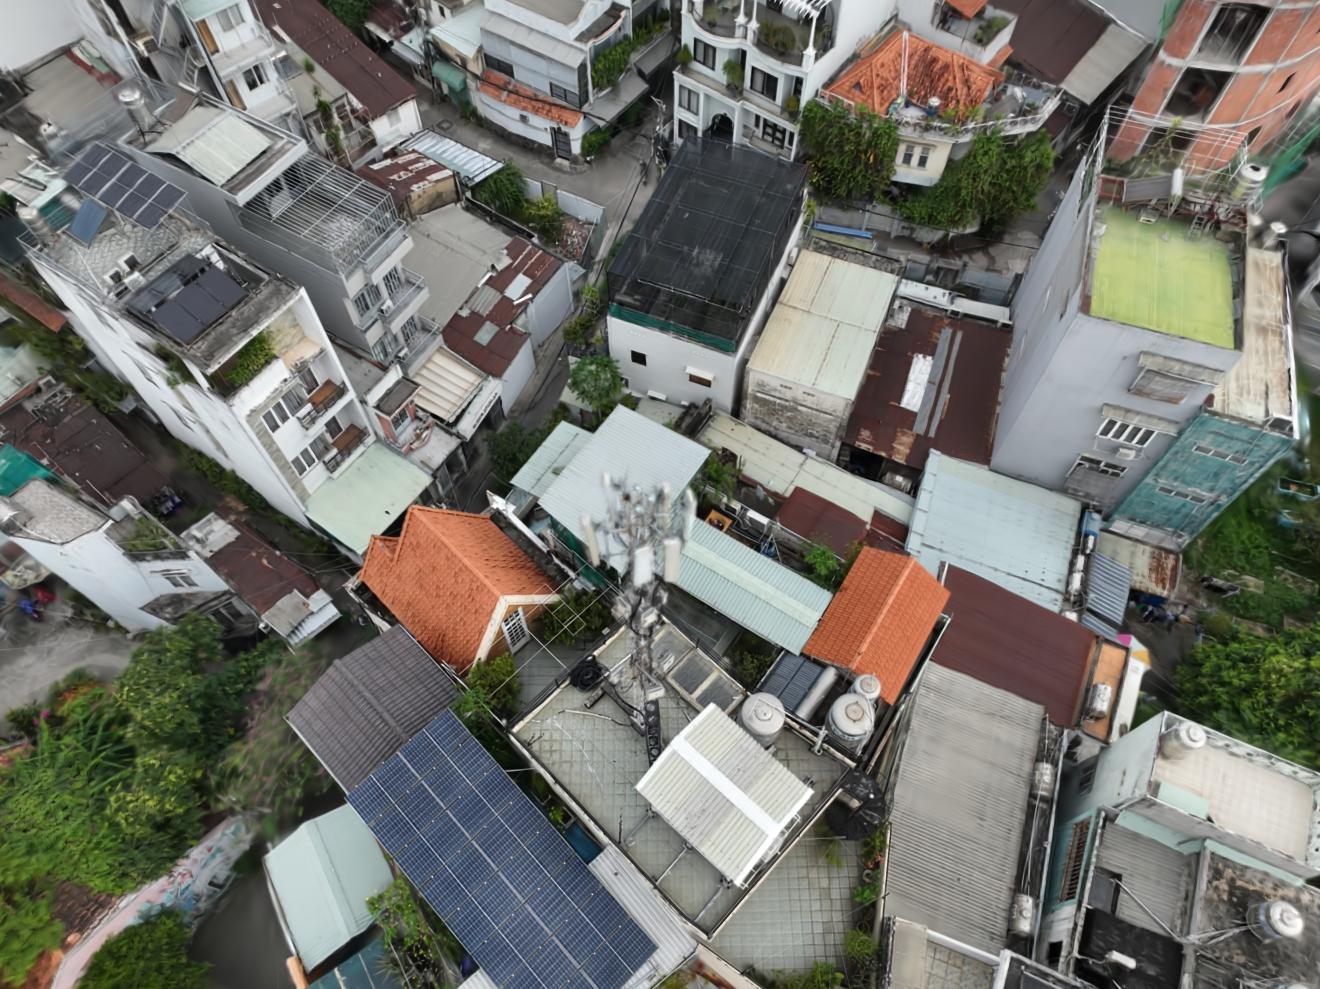

DJI_20241230093355_0017_V.JPG


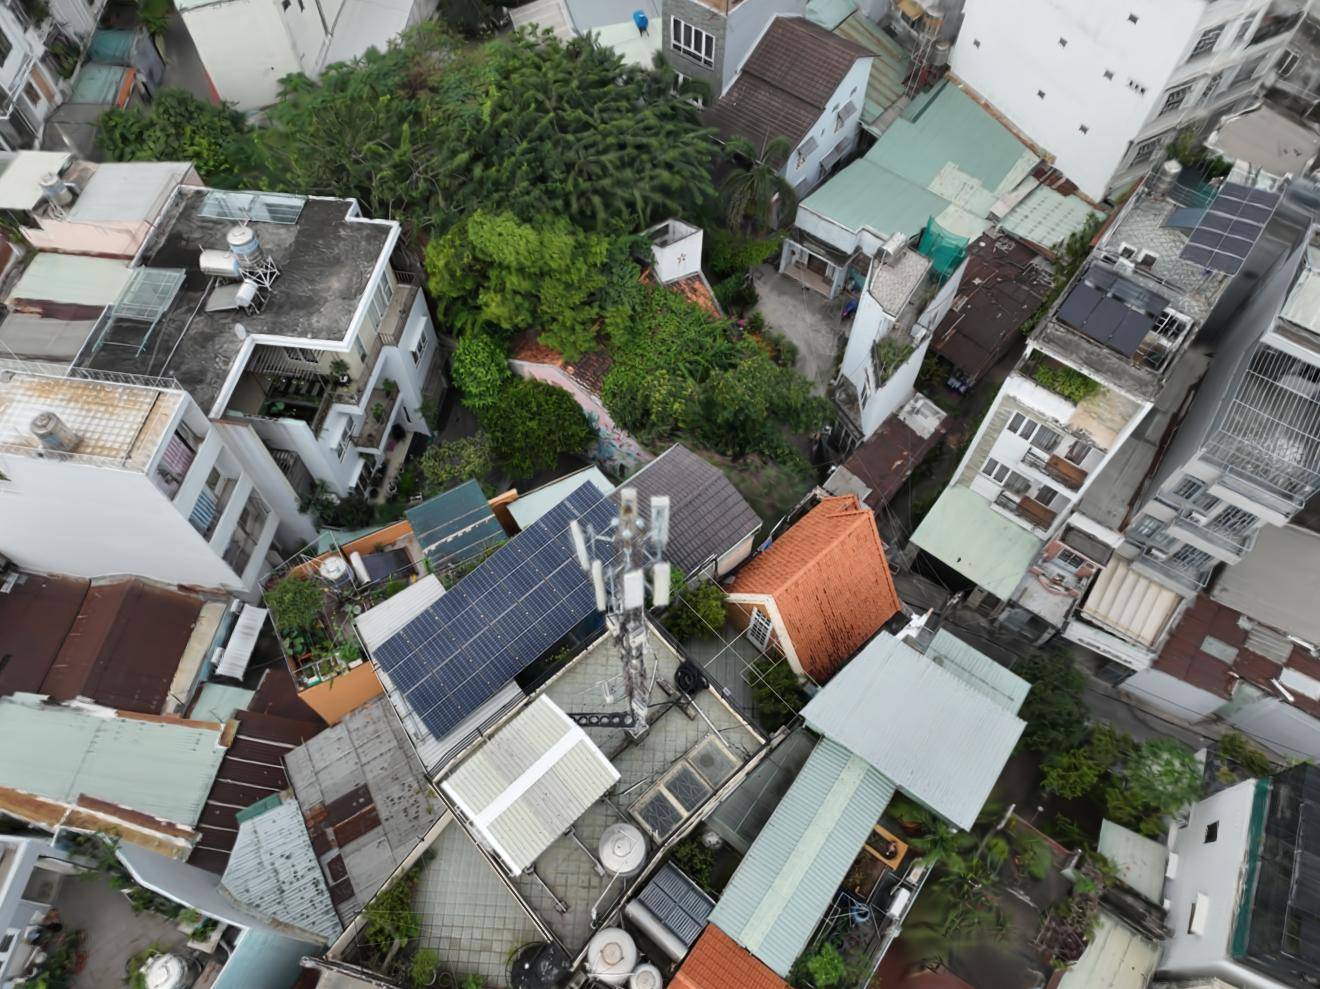

In [ ]:
from IPython.display import Image, display
import os
d = f'{SUBMISSION}/HCM0421'
for f in sorted(os.listdir(d))[:2]:
    print(f); display(Image(f'{d}/{f}', width=420))

In [ ]:
!cd {SUBMISSION} && zip -qr /content/submission_round1.zip .
!python /content/tools/validate_submission.py \
    --zip /content/submission_round1.zip --data-dir "{DATA_DRIVE}"

Tìm thấy 7 scene trong dữ liệu: ['HCM0421', 'HCM0539', 'HCM0540', 'HCM0644', 'HCM0674', 'bonsai', 'chair']
  HCM0421: 60/60 ảnh khớp CSV
  HCM0539: 60/60 ảnh khớp CSV
  HCM0540: 60/60 ảnh khớp CSV
  HCM0644: 60/60 ảnh khớp CSV
  HCM0674: 60/60 ảnh khớp CSV
  bonsai: 28/28 ảnh khớp CSV
  chair: 58/58 ảnh khớp CSV


===> OK: Submission hợp lệ, sẵn sàng nộp!


In [ ]:
import shutil
shutil.copy('/content/submission_round1.zip', f'{DRIVE_ROOT}/submission_round1.zip')
print('Xong:', f'{DRIVE_ROOT}/submission_round1.zip')

Xong: /content/drive/MyDrive/VAR2026/submission_round1.zip
